# Ngày 2 — từ gán nhãn đến bộ phát hiện vật thể

Bài thực hành 4 giờ triển khai đầy đủ yêu cầu trên bài giảng: áp dụng bốn lớp `car` (ô tô con), `truck` (xe tải),
`bus` (xe buýt), `van` (xe van); gán 40–60 vật thể trong CVAT; xuất YOLO (định dạng nhãn phát hiện vật thể);
huấn luyện thử bằng Ultralytics (thư viện huấn luyện mô hình); đối chiếu IoU (mức giao trên hợp của hai hộp) với
bạn cùng cặp hoặc bộ nhãn do Lab Coach (người hướng dẫn thực hành) cấp; rồi nộp phiếu quy
tắc và các minh chứng.
**Luồng chính không yêu cầu viết hoặc sửa mã nguồn.**

Mỗi người phải gán nhãn độc lập trước khi xem nguồn đối chiếu. IoU và mAP (độ chính xác trung bình theo nhiều
ngưỡng) là tín hiệu chẩn đoán, không phải điểm
đạt, không chứng minh nhãn đúng và không phải phép đánh giá mô hình dùng trong thực tế. Không đưa dữ liệu
VinFast, dữ liệu khách hàng, ảnh cá nhân hoặc mã truy cập vào sổ thực hành hay repo.


## Trước khi chạy các ô lệnh — hoàn tất CVAT độc lập

Lấy trực tiếp `data/day2-cvat-input.zip` từ repo của lớp và làm theo `GUIDE.md`. Gói ZIP đã chứa đủ bốn ảnh;
sổ thực hành không tạo hoặc tải ảnh. Tạo dự án với đúng bốn lớp và ba thuộc tính, gán nhãn toàn bộ bốn ảnh,
tự kiểm tra chất lượng rồi xuất từ **cùng một tác vụ/công việc**:

1. `Ultralytics YOLO Detection` kèm ảnh để giữ lớp và hộp;
2. `CVAT for images 1.1` để giữ các thuộc tính.

Chỉ chạy các ô lệnh bên dưới sau khi đã có hai gói xuất của chính bạn. Người làm theo cặp không xem tác vụ hay
gói xuất của nhau trước khi cả hai hoàn thành. Người làm cá nhân chỉ nhận bộ nhãn đối chiếu sau khi đã kiểm bài mình.


In [ ]:
# 0a — Cài đúng phiên bản của bài thực hành; chờ ô lệnh chạy xong.
%pip -q install ultralytics==8.4.145 certifi==2026.6.17


In [7]:
"""Các hàm hỗ trợ đã kiểm thử và được nhúng vào sổ thực hành Ngày 2."""

import csv
import hashlib
import json
import math
import shutil
import ssl
import stat
import urllib.request
import zipfile
import xml.etree.ElementTree as ET
from collections import defaultdict
from pathlib import Path, PurePosixPath

import numpy as np
import yaml
import certifi
from PIL import Image, ImageDraw
from scipy.optimize import linear_sum_assignment


IMAGE_SUFFIXES = {".jpg", ".jpeg", ".png", ".webp"}
EXPECTED_CLASS_NAMES = ["car", "truck", "bus", "van"]
REQUIRED_ATTRIBUTE_VALUES = {
    "visibility": {"clear", "occluded", "unclear"},
    "boundary": {"inside", "truncated"},
    "review_state": {"confident", "needs_review"},
}


def sha256_file(path: str | Path) -> str:
    digest = hashlib.sha256()
    with Path(path).open("rb") as stream:
        for chunk in iter(lambda: stream.read(1024 * 1024), b""):
            digest.update(chunk)
    return digest.hexdigest()


def download_with_sha256(label: str, url: str, target: str | Path, expected: str) -> Path:
    """Tải tệp theo cách an toàn và từ chối nội dung sai mã SHA-256."""
    target = Path(target)
    target.parent.mkdir(parents=True, exist_ok=True)
    if target.exists() and sha256_file(target) == expected:
        return target
    if target.exists():
        target.unlink()
    temporary = target.with_name(f".{target.name}.download")
    if temporary.exists():
        temporary.unlink()
    try:
        request = urllib.request.Request(url, headers={"User-Agent": "AI20K-Day2-Lab/1.0"})
        tls_context = ssl.create_default_context(cafile=certifi.where())
        with urllib.request.urlopen(request, timeout=60, context=tls_context) as response, temporary.open("wb") as output:
            shutil.copyfileobj(response, output)
        actual = sha256_file(temporary)
        if actual != expected:
            raise ValueError(f"Checksum sai cho {label}: expected={expected}, actual={actual}")
        temporary.replace(target)
    finally:
        if temporary.exists():
            temporary.unlink()
    return target


def read_manifest(path: str | Path) -> list[dict]:
    with Path(path).open(encoding="utf-8", newline="") as stream:
        rows = list(csv.DictReader(stream))
    if not rows:
        raise ValueError("Image manifest rỗng")
    required = {
        "image_id",
        "local_path",
        "sha256",
        "width",
        "height",
        "split",
        "role",
        "origin_claim",
        "origin_record_status",
        "starter_repository",
        "starter_commit",
        "license_claim",
        "license_url",
    }
    missing = required - set(rows[0])
    if missing:
        raise ValueError(f"Manifest thiếu cột: {sorted(missing)}")
    seen = set()
    for row in rows:
        if row["image_id"] in seen:
            raise ValueError(f"Manifest lặp image_id: {row['image_id']}")
        seen.add(row["image_id"])
        row["width"] = int(row["width"])
        row["height"] = int(row["height"])
        if row["split"] not in {"train", "val"}:
            raise ValueError(f"Split không hợp lệ: {row['split']}")
        if len(row["sha256"]) != 64:
            raise ValueError(f"SHA-256 không hợp lệ: {row['image_id']}")
    return rows


def safe_extract_zip(archive_path: str | Path, destination: str | Path, max_bytes: int = 300_000_000) -> Path:
    """Giải nén an toàn, chặn đường dẫn thoát, liên kết mềm và gói ZIP quá lớn."""
    archive_path = Path(archive_path)
    destination = Path(destination)
    with zipfile.ZipFile(archive_path) as archive:
        total = 0
        for item in archive.infolist():
            parts = PurePosixPath(item.filename).parts
            if not parts or item.filename.startswith(("/", "\\")) or ".." in parts:
                raise ValueError(f"ZIP có đường dẫn không an toàn: {item.filename}")
            if stat.S_ISLNK(item.external_attr >> 16):
                raise ValueError(f"ZIP chứa symlink không được phép: {item.filename}")
            total += item.file_size
            if total > max_bytes:
                raise ValueError("ZIP vượt giới hạn 300 MB của lab")
        if destination.exists():
            shutil.rmtree(destination)
        destination.mkdir(parents=True)
        archive.extractall(destination)
    return destination


def _normalize_names(raw_names) -> list[str]:
    if isinstance(raw_names, list):
        return [str(value) for value in raw_names]
    if isinstance(raw_names, dict):
        pairs = sorted((int(key), str(value)) for key, value in raw_names.items())
        if [key for key, _ in pairs] != list(range(len(pairs))):
            raise ValueError("Class IDs trong data.yaml phải liên tiếp từ 0")
        return [value for _, value in pairs]
    raise ValueError("data.yaml phải có names dạng list hoặc mapping")


def _find_yolo_root(extracted: Path) -> tuple[Path, list[str]]:
    candidates = sorted({*extracted.rglob("data.yaml"), *extracted.rglob("dataset.yaml")})
    for candidate in candidates:
        data = yaml.safe_load(candidate.read_text(encoding="utf-8"))
        if isinstance(data, dict) and "names" in data:
            return candidate.parent, _normalize_names(data["names"])
    raise ValueError("Không tìm thấy data.yaml/dataset.yaml có class names trong YOLO export")


def _unique_stem_map(paths: list[Path], kind: str) -> dict[str, Path]:
    result = {}
    for path in paths:
        stem = path.stem
        if stem in result:
            raise ValueError(f"Có hai {kind} trùng stem `{stem}`")
        result[stem] = path
    return result


def _parse_label_file(path: Path, image_id: str, width: int, height: int, names: list[str]) -> list[dict]:
    records = []
    for row_number, raw_line in enumerate(path.read_text(encoding="utf-8").splitlines(), start=1):
        line = raw_line.strip()
        if not line:
            continue
        values = line.split()
        if len(values) != 5:
            raise ValueError(f"{path.name}:{row_number} cần đúng 5 trường, nhận {len(values)}")
        try:
            class_id = int(values[0])
            x_center, y_center, box_width, box_height = map(float, values[1:])
        except ValueError as error:
            raise ValueError(f"{path.name}:{row_number} có giá trị không phải số") from error
        coords = (x_center, y_center, box_width, box_height)
        if not all(math.isfinite(value) for value in coords):
            raise ValueError(f"{path.name}:{row_number} có NaN/Infinity")
        if not 0 <= class_id < len(names):
            raise ValueError(f"{path.name}:{row_number} có class_id ngoài schema: {class_id}")
        if not (0 <= x_center <= 1 and 0 <= y_center <= 1):
            raise ValueError(f"{path.name}:{row_number} có tâm ngoài [0,1]")
        if not (0 < box_width <= 1 and 0 < box_height <= 1):
            raise ValueError(f"{path.name}:{row_number} có width/height không hợp lệ")
        x1 = x_center - box_width / 2
        y1 = y_center - box_height / 2
        x2 = x_center + box_width / 2
        y2 = y_center + box_height / 2
        if min(x1, y1) < -1e-6 or max(x2, y2) > 1 + 1e-6:
            raise ValueError(f"{path.name}:{row_number} có box vượt biên ảnh")
        records.append(
            {
                "image_id": image_id,
                "row_number": row_number,
                "class_id": class_id,
                "class_name": names[class_id],
                "bbox_xywh_normalized": [x_center, y_center, box_width, box_height],
                "bbox_xyxy_normalized": [max(0, x1), max(0, y1), min(1, x2), min(1, y2)],
                "bbox_xyxy_pixels": [x1 * width, y1 * height, x2 * width, y2 * height],
            }
        )
    return records


def audit_yolo_export(
    archive_path: str | Path,
    destination: str | Path,
    manifest_rows: list[dict],
    expected_names: list[str] | None = None,
) -> tuple[dict, list[dict]]:
    expected_names = expected_names or EXPECTED_CLASS_NAMES
    extracted = safe_extract_zip(archive_path, destination)
    root, names = _find_yolo_root(extracted)
    if names != expected_names:
        raise ValueError(f"Schema export {names} không khớp schema lớp {expected_names}")

    image_paths = [path for path in root.rglob("*") if path.suffix.lower() in IMAGE_SUFFIXES]
    label_paths = [path for path in root.rglob("*.txt") if "labels" in path.parts]
    images = _unique_stem_map(image_paths, "ảnh")
    labels = _unique_stem_map(label_paths, "label")
    expected_ids = [row["image_id"] for row in manifest_rows]
    expected_id_set = set(expected_ids)
    extra_images = sorted(set(images) - expected_id_set)
    extra_labels = sorted(set(labels) - expected_id_set)
    if extra_images or extra_labels:
        raise ValueError(f"YOLO export có file ngoài pool; ảnh thừa={extra_images}, label thừa={extra_labels}")
    records = []
    image_details = {}
    manifest_by_id = {row["image_id"]: row for row in manifest_rows}
    for image_id in expected_ids:
        if image_id not in images:
            raise ValueError(f"YOLO export thiếu ảnh `{image_id}`; hãy bật export kèm ảnh")
        if image_id not in labels:
            raise ValueError(f"YOLO export thiếu label `{image_id}.txt`")
        with Image.open(images[image_id]) as image:
            image.verify()
        with Image.open(images[image_id]) as image:
            width, height = image.size
        expected = manifest_by_id[image_id]
        if (width, height) != (expected["width"], expected["height"]):
            raise ValueError(
                f"Kích thước `{image_id}` là {width}x{height}, cần {expected['width']}x{expected['height']}"
            )
        image_records = _parse_label_file(labels[image_id], image_id, width, height, names)
        records.extend(image_records)
        class_counts = {name: 0 for name in names}
        for record in image_records:
            class_counts[record["class_name"]] += 1
        image_details[image_id] = {
            "image_path": str(images[image_id]),
            "label_path": str(labels[image_id]),
            "width": width,
            "height": height,
            "object_count": len(image_records),
            "class_count": class_counts,
        }
    object_count = len(records)
    report = {
        "archive_name": Path(archive_path).name,
        "archive_sha256": sha256_file(archive_path),
        "class_names": names,
        "image_ids": expected_ids,
        "image_count": len(expected_ids),
        "object_count": object_count,
        "within_slide_workload_target": 40 <= object_count <= 60,
        "coordinate_format": "normalized xywh",
        "images": image_details,
    }
    return report, records


def public_audit_report(report: dict) -> dict:
    """Loại đường dẫn cục bộ khỏi báo cáo trước khi nộp."""
    clean = json.loads(json.dumps(report))
    clean.pop("_records", None)
    for details in clean.get("images", {}).values():
        details.pop("image_path", None)
        details.pop("label_path", None)
    return clean


def write_audit_report(report: dict, target: str | Path) -> Path:
    target = Path(target)
    target.parent.mkdir(parents=True, exist_ok=True)
    target.write_text(json.dumps(public_audit_report(report), ensure_ascii=False, indent=2) + "\n", encoding="utf-8")
    return target


def audit_cvat_images_export(
    archive_path: str | Path,
    destination: str | Path,
    manifest_rows: list[dict],
    expected_names: list[str] | None = None,
) -> dict:
    """Kiểm dữ liệu XML và thuộc tính mà định dạng YOLO không giữ lại."""
    expected_names = expected_names or EXPECTED_CLASS_NAMES
    extracted = safe_extract_zip(archive_path, destination)
    annotation_files = sorted(extracted.rglob("annotations.xml"))
    if len(annotation_files) != 1:
        raise ValueError("CVAT-native export cần đúng một file annotations.xml")
    try:
        root = ET.parse(annotation_files[0]).getroot()
    except ET.ParseError as error:
        raise ValueError("annotations.xml của CVAT không đọc được") from error

    manifest_by_id = {row["image_id"]: row for row in manifest_rows}
    images_by_id = {}
    for image in root.findall("image"):
        image_id = Path(image.attrib.get("name", "")).stem
        if image_id in images_by_id:
            raise ValueError(f"CVAT-native export có hai image trùng ID `{image_id}`")
        images_by_id[image_id] = image

    expected_ids = [row["image_id"] for row in manifest_rows]
    if set(images_by_id) != set(expected_ids):
        missing = sorted(set(expected_ids) - set(images_by_id))
        unexpected = sorted(set(images_by_id) - set(expected_ids))
        raise ValueError(f"CVAT-native export sai image IDs; thiếu={missing}, thừa={unexpected}")

    attribute_counts = {name: 0 for name in REQUIRED_ATTRIBUTE_VALUES}
    object_count = 0
    per_image = {}
    native_records = []
    for image_id in expected_ids:
        image = images_by_id[image_id]
        expected = manifest_by_id[image_id]
        try:
            width = int(image.attrib["width"])
            height = int(image.attrib["height"])
        except (KeyError, ValueError) as error:
            raise ValueError(f"CVAT-native image `{image_id}` thiếu width/height hợp lệ") from error
        if (width, height) != (expected["width"], expected["height"]):
            raise ValueError(
                f"Kích thước CVAT-native `{image_id}` là {width}x{height}, "
                f"cần {expected['width']}x{expected['height']}"
            )
        boxes = image.findall("box")
        non_boxes = [child.tag for child in image if child.tag != "box"]
        if non_boxes:
            raise ValueError(f"CVAT-native `{image_id}` có shape không phải rectangle: {non_boxes}")
        for row_number, box in enumerate(boxes, start=1):
            label = box.attrib.get("label")
            if label not in expected_names:
                raise ValueError(f"CVAT-native `{image_id}` box {row_number} có class lạ `{label}`")
            try:
                xtl, ytl, xbr, ybr = (float(box.attrib[key]) for key in ("xtl", "ytl", "xbr", "ybr"))
            except (KeyError, ValueError) as error:
                raise ValueError(f"CVAT-native `{image_id}` box {row_number} có tọa độ không hợp lệ") from error
            coords = (xtl, ytl, xbr, ybr)
            if not all(math.isfinite(value) for value in coords) or not (0 <= xtl < xbr <= width and 0 <= ytl < ybr <= height):
                raise ValueError(f"CVAT-native `{image_id}` box {row_number} vượt biên hoặc có diện tích không dương")
            attributes = {}
            for attribute in box.findall("attribute"):
                name = attribute.attrib.get("name")
                if name in attributes:
                    raise ValueError(f"CVAT-native `{image_id}` box {row_number} lặp attribute `{name}`")
                attributes[name] = (attribute.text or "").strip()
            if set(attributes) != set(REQUIRED_ATTRIBUTE_VALUES):
                raise ValueError(
                    f"CVAT-native `{image_id}` box {row_number} cần đúng attributes "
                    f"{sorted(REQUIRED_ATTRIBUTE_VALUES)}, nhận {sorted(attributes)}"
                )
            for name, allowed_values in REQUIRED_ATTRIBUTE_VALUES.items():
                if attributes[name] not in allowed_values:
                    raise ValueError(
                        f"CVAT-native `{image_id}` box {row_number} có {name}=`{attributes[name]}` không hợp lệ"
                    )
                attribute_counts[name] += 1
            native_records.append(
                {
                    "image_id": image_id,
                    "row_number": row_number,
                    "class_id": expected_names.index(label),
                    "class_name": label,
                    "bbox_xyxy_normalized": [xtl / width, ytl / height, xbr / width, ybr / height],
                }
            )
            object_count += 1
        class_counts = {name: 0 for name in expected_names}
        for record in native_records:
            if record["image_id"] == image_id:
                class_counts[record["class_name"]] += 1
        per_image[image_id] = {
            "width": width,
            "height": height,
            "object_count": len(boxes),
            "class_count": class_counts,
        }
    return {
        "archive_name": Path(archive_path).name,
        "archive_sha256": sha256_file(archive_path),
        "format": "CVAT for images XML",
        "class_names": expected_names,
        "image_ids": expected_ids,
        "image_count": len(expected_ids),
        "object_count": object_count,
        "within_slide_workload_target": 40 <= object_count <= 60,
        "required_attributes": sorted(REQUIRED_ATTRIBUTE_VALUES),
        "attribute_value_count_by_name": attribute_counts,
        "images": per_image,
        "_records": native_records,
    }


def verify_same_annotation_state(
    yolo_records: list[dict],
    native_records: list[dict],
    image_ids: list[str],
    minimum_iou: float = 0.995,
) -> dict:
    """Xác minh hai bản xuất giữ cùng lớp và hình học hộp, cho phép sai số làm tròn nhỏ."""
    if not 0 < minimum_iou <= 1:
        raise ValueError("minimum_iou phải nằm trong (0,1]")
    yolo_by_key = defaultdict(list)
    native_by_key = defaultdict(list)
    for record in yolo_records:
        yolo_by_key[(record["image_id"], record["class_name"])].append(record)
    for record in native_records:
        native_by_key[(record["image_id"], record["class_name"])].append(record)

    matched_ious = []
    for image_id in image_ids:
        for class_name in EXPECTED_CLASS_NAMES:
            left = yolo_by_key[(image_id, class_name)]
            right = native_by_key[(image_id, class_name)]
            if len(left) != len(right):
                raise AssertionError(
                    f"Hai gói xuất khác số hộp lớp `{class_name}` ở ảnh `{image_id}`: "
                    f"YOLO={len(left)}, CVAT={len(right)}. Xuất lại cả hai từ cùng trạng thái."
                )
            if not left:
                continue
            matrix = np.zeros((len(left), len(right)), dtype=float)
            for left_index, left_record in enumerate(left):
                for right_index, right_record in enumerate(right):
                    matrix[left_index, right_index] = box_iou(
                        left_record["bbox_xyxy_normalized"], right_record["bbox_xyxy_normalized"]
                    )
            left_indices, right_indices = linear_sum_assignment(-matrix)
            class_ious = [float(matrix[i, j]) for i, j in zip(left_indices, right_indices)]
            if class_ious and min(class_ious) < minimum_iou:
                raise AssertionError(
                    f"Hai gói xuất khác hình học hộp ở ảnh `{image_id}`, lớp `{class_name}`; "
                    f"IoU nhỏ nhất={min(class_ious):.6f}. Xuất lại cả hai từ cùng trạng thái."
                )
            matched_ious.extend(class_ious)
    if len(yolo_records) != len(native_records):
        raise AssertionError("Hai gói xuất khác tổng số hộp; xuất lại cả hai từ cùng trạng thái.")
    return {
        "same_annotation_state": True,
        "matched_box_count": len(matched_ious),
        "minimum_cross_format_iou": min(matched_ious) if matched_ious else None,
        "geometry_iou_floor": minimum_iou,
    }


def box_iou(left: list[float], right: list[float]) -> float:
    x1 = max(left[0], right[0])
    y1 = max(left[1], right[1])
    x2 = min(left[2], right[2])
    y2 = min(left[3], right[3])
    intersection = max(0.0, x2 - x1) * max(0.0, y2 - y1)
    left_area = max(0.0, left[2] - left[0]) * max(0.0, left[3] - left[1])
    right_area = max(0.0, right[2] - right[0]) * max(0.0, right[3] - right[1])
    union = left_area + right_area - intersection
    return intersection / union if union else 0.0


def compare_annotation_records(
    mine: list[dict],
    comparison: list[dict],
    calibration_ids: list[str],
    comparison_source: str,
    comparison_iou_floor: float = 0.01,
) -> tuple[dict, list[dict]]:
    """Đối chiếu bài độc lập với bạn cùng cặp hoặc bộ nhãn do Lab Coach cấp."""
    if not 0 <= comparison_iou_floor <= 1:
        raise ValueError("comparison_iou_floor phải nằm trong [0,1]")
    if comparison_source not in {"peer", "teaching_reference"}:
        raise ValueError("comparison_source phải là peer hoặc teaching_reference")
    mine_by_image = defaultdict(list)
    comparison_by_image = defaultdict(list)
    for record in mine:
        mine_by_image[record["image_id"]].append(record)
    for record in comparison:
        comparison_by_image[record["image_id"]].append(record)

    rows = []
    unmatched_mine = 0
    unmatched_comparison = 0
    for image_id in calibration_ids:
        left = mine_by_image[image_id]
        right = comparison_by_image[image_id]
        matrix = np.zeros((len(left), len(right)), dtype=float)
        for i, left_record in enumerate(left):
            for j, right_record in enumerate(right):
                matrix[i, j] = box_iou(
                    left_record["bbox_xyxy_normalized"], right_record["bbox_xyxy_normalized"]
                )
        candidates = []
        if matrix.size:
            left_indices, right_indices = linear_sum_assignment(-matrix)
            candidates = list(zip(left_indices.tolist(), right_indices.tolist()))
        matched_left = set()
        matched_right = set()
        for left_index, right_index in candidates:
            iou = float(matrix[left_index, right_index])
            if iou < comparison_iou_floor:
                continue
            matched_left.add(left_index)
            matched_right.add(right_index)
            left_record = left[left_index]
            right_record = right[right_index]
            rows.append(
                {
                    "image_id": image_id,
                    "mine_row": left_record["row_number"],
                    "comparison_row": right_record["row_number"],
                    "iou": round(iou, 6),
                    "mine_class": left_record["class_name"],
                    "comparison_class": right_record["class_name"],
                    "class_agree": left_record["class_id"] == right_record["class_id"],
                }
            )
        unmatched_mine += len(left) - len(matched_left)
        unmatched_comparison += len(right) - len(matched_right)

    ious = [row["iou"] for row in rows]
    class_agreements = [row["class_agree"] for row in rows]
    if comparison_source == "peer":
        interpretation_warning = (
            "Mức đồng thuận giữa hai người đo khả năng tái lập quy tắc, không chứng minh cả hai đều đúng."
        )
    else:
        interpretation_warning = (
            "Bộ nhãn đối chiếu hỗ trợ phản hồi sau bài làm độc lập; đây không phải kết luận chất lượng sản xuất."
        )
    summary = {
        "matching": "ghép tối ưu theo IoU hình học, không dùng lớp khi ghép",
        "comparison_iou_floor": comparison_iou_floor,
        "floor_is_official_pass_threshold": False,
        "calibration_image_ids": calibration_ids,
        "matched_boxes": len(rows),
        "mean_iou": round(float(np.mean(ious)), 6) if ious else None,
        "median_iou": round(float(np.median(ious)), 6) if ious else None,
        "class_agreement": round(sum(class_agreements) / len(class_agreements), 6) if class_agreements else None,
        "unmatched_mine": unmatched_mine,
        "unmatched_comparison": unmatched_comparison,
        "comparison_source": comparison_source,
        "interpretation_warning": interpretation_warning,
    }
    return summary, rows


def write_annotation_comparison(summary: dict, rows: list[dict], output_dir: str | Path) -> tuple[Path, Path]:
    output_dir = Path(output_dir)
    output_dir.mkdir(parents=True, exist_ok=True)
    summary_path = output_dir / "comparison_summary.json"
    csv_path = output_dir / "comparison_iou.csv"
    summary_path.write_text(json.dumps(summary, ensure_ascii=False, indent=2) + "\n", encoding="utf-8")
    fieldnames = [
        "image_id", "mine_row", "comparison_row", "iou", "mine_class", "comparison_class", "class_agree"
    ]
    with csv_path.open("w", encoding="utf-8", newline="") as stream:
        writer = csv.DictWriter(stream, fieldnames=fieldnames)
        writer.writeheader()
        writer.writerows(rows)
    return summary_path, csv_path


def create_comparison_overlay(
    mine_report: dict,
    mine_records: list[dict],
    comparison_records: list[dict],
    calibration_ids: list[str],
    target: str | Path,
    comparison_source: str,
) -> Path:
    cards = []
    mine_by_image = defaultdict(list)
    comparison_by_image = defaultdict(list)
    for record in mine_records:
        mine_by_image[record["image_id"]].append(record)
    for record in comparison_records:
        comparison_by_image[record["image_id"]].append(record)
    for image_id in calibration_ids:
        image_path = mine_report["images"][image_id]["image_path"]
        image = Image.open(image_path).convert("RGB")
        draw = ImageDraw.Draw(image)
        for record in mine_by_image[image_id]:
            draw.rectangle(record["bbox_xyxy_pixels"], outline="#ff304f", width=3)
        for record in comparison_by_image[image_id]:
            draw.rectangle(record["bbox_xyxy_pixels"], outline="#00a8ff", width=3)
        image.thumbnail((720, 480))
        card = Image.new("RGB", (740, 530), "white")
        card.paste(image, ((740 - image.width) // 2, 35))
        comparison_label = "bạn cùng cặp" if comparison_source == "peer" else "bộ nhãn đối chiếu"
        ImageDraw.Draw(card).text((12, 10), f"{image_id} | đỏ: tôi | xanh: {comparison_label}", fill="black")
        cards.append(card)
    canvas = Image.new("RGB", (740, 530 * len(cards)), "#dddddd")
    for index, card in enumerate(cards):
        canvas.paste(card, (0, index * 530))
    target = Path(target)
    target.parent.mkdir(parents=True, exist_ok=True)
    canvas.save(target, quality=92)
    return target


def build_training_dataset(
    report: dict,
    manifest_rows: list[dict],
    class_names: list[str],
    destination: str | Path,
) -> Path:
    destination = Path(destination)
    if destination.exists():
        shutil.rmtree(destination)
    for split in ("train", "val"):
        (destination / "images" / split).mkdir(parents=True, exist_ok=True)
        (destination / "labels" / split).mkdir(parents=True, exist_ok=True)
    for row in manifest_rows:
        image_id = row["image_id"]
        split = row["split"]
        details = report["images"][image_id]
        image_source = Path(details["image_path"])
        label_source = Path(details["label_path"])
        shutil.copy2(image_source, destination / "images" / split / image_source.name)
        shutil.copy2(label_source, destination / "labels" / split / f"{image_id}.txt")
    config = {
        "path": str(destination.resolve()),
        "train": "images/train",
        "val": "images/val",
        "names": {index: name for index, name in enumerate(class_names)},
    }
    yaml_path = destination / "data.yaml"
    yaml_path.write_text(yaml.safe_dump(config, sort_keys=False, allow_unicode=True), encoding="utf-8")
    return yaml_path


def write_attribution(manifest_rows: list[dict], target: str | Path) -> Path:
    lines = [
        "# Nguồn gốc ảnh",
        "",
        "Bốn ảnh giao thông được lấy nguyên vẹn từ kho nguồn của giảng viên tại phiên bản Git đã ghi bên dưới.",
        "Kho nguồn cho biết ảnh bắt nguồn từ UA-DETRAC qua một bản tái xuất trên Hugging Face và thẻ dữ liệu khi đó công bố CC BY 4.0.",
        "Kho nguồn đã đổi tên ảnh và không giữ mã bản ghi gốc; liên kết bản tái xuất hiện không còn truy cập được. Đây là giới hạn truy nguyên được công bố rõ, không phải xác minh pháp lý độc lập.",
        "Ảnh phủ hộp và ảnh dự đoán là sản phẩm đã chỉnh sửa; các quyền khác vẫn có thể áp dụng.",
        "",
        "| Mã ảnh | Công bố nguồn / trạng thái bản ghi | Kho nguồn và phiên bản | Công bố giấy phép | SHA-256 |",
        "| --- | --- | --- | --- | --- |",
    ]
    for row in manifest_rows:
        lines.append(
            f"| `{row['image_id']}` | {row['origin_claim']} / {row['origin_record_status']} | "
            f"[{row['starter_commit'][:7]}]({row['starter_repository']}/tree/{row['starter_commit']}) | "
            f"[{row['license_claim']}]({row['license_url']}) | "
            f"`{row['sha256']}` |"
        )
    target = Path(target)
    target.parent.mkdir(parents=True, exist_ok=True)
    target.write_text("\n".join(lines) + "\n", encoding="utf-8")
    return target


In [8]:
# 0b — Kiểm tra môi trường và tạo thư mục làm việc.
# Chạy lại ô này sẽ xóa đầu ra tạm của phiên hiện tại, không xóa tệp trên Google Drive.
import io
import os
import re
import shutil
import time
import zipfile
from pathlib import Path

import matplotlib.pyplot as plt
import torch
import ultralytics
from PIL import Image
from ultralytics import YOLO

ULTRALYTICS_VERSION_PIN = "8.4.145"
INPUT_ZIP_SHA256 = "f7d99888f21440fb0374d84962b93213bd8c14e665d093cc8d37f4c61b71ed33"
assert ultralytics.__version__ == ULTRALYTICS_VERSION_PIN, (
    f"Sai Ultralytics {ultralytics.__version__}; cần {ULTRALYTICS_VERSION_PIN}"
)
WORK_DIR = Path("/content/day2_lab") if Path("/content").exists() else Path("day2_lab")
OUTPUT_DIR = Path("day2_lab_outputs")
UPLOAD_DIR = WORK_DIR / "uploads"
MANIFEST_PATH = WORK_DIR / "image-manifest.csv"
REPORT_PATH = Path("REPORT.md")
GUIDELINE_PATH = Path("GUIDELINE_MINI_SHEET.md")
for path in (WORK_DIR, OUTPUT_DIR):
    if path.exists():
        shutil.rmtree(path)
for path in (UPLOAD_DIR, OUTPUT_DIR):
    path.mkdir(parents=True, exist_ok=True)

MANIFEST_CSV = 'image_id,local_path,sha256,width,height,split,role,origin_claim,origin_record_status,starter_repository,starter_commit,license_claim,license_url\ndrive_022,data/cvat-input/drive_022.jpg,cb8297af4cc5bb660f9d56f0e31ed77f8fa1f95b31f47bb8b8a1cd08b2f94886,640,640,train,comparison,UA-DETRAC qua bản tái xuất SQiFeng/traffic-vehicle-detection,Kho nguồn đã đổi tên và không lưu mã bản ghi ảnh gốc,https://github.com/VinUni-AI20k/Day2-TrackData-ObjectDetection,710d2c157c5750f71271354d0d31b24457c64e7c,CC BY 4.0 theo công bố của thẻ dữ liệu bản tái xuất,https://creativecommons.org/licenses/by/4.0/\ndrive_033,data/cvat-input/drive_033.jpg,8dc05a7a8f06ed137d08b643ef676629a2c4cf3b25051852de22e7400311e465,640,640,train,comparison,UA-DETRAC qua bản tái xuất SQiFeng/traffic-vehicle-detection,Kho nguồn đã đổi tên và không lưu mã bản ghi ảnh gốc,https://github.com/VinUni-AI20k/Day2-TrackData-ObjectDetection,710d2c157c5750f71271354d0d31b24457c64e7c,CC BY 4.0 theo công bố của thẻ dữ liệu bản tái xuất,https://creativecommons.org/licenses/by/4.0/\ndrive_038,data/cvat-input/drive_038.jpg,35294a107b157646e0619ad985226ef424968d7798f90f7ded5b32f32cebbb86,640,640,train,comparison,UA-DETRAC qua bản tái xuất SQiFeng/traffic-vehicle-detection,Kho nguồn đã đổi tên và không lưu mã bản ghi ảnh gốc,https://github.com/VinUni-AI20k/Day2-TrackData-ObjectDetection,710d2c157c5750f71271354d0d31b24457c64e7c,CC BY 4.0 theo công bố của thẻ dữ liệu bản tái xuất,https://creativecommons.org/licenses/by/4.0/\ndrive_008,data/cvat-input/drive_008.jpg,fde088a7a955343bb3366008d31e3c2a6ecf6ddbfd08e58ecd91f5e6d67a05d1,640,640,val,comparison,UA-DETRAC qua bản tái xuất SQiFeng/traffic-vehicle-detection,Kho nguồn đã đổi tên và không lưu mã bản ghi ảnh gốc,https://github.com/VinUni-AI20k/Day2-TrackData-ObjectDetection,710d2c157c5750f71271354d0d31b24457c64e7c,CC BY 4.0 theo công bố của thẻ dữ liệu bản tái xuất,https://creativecommons.org/licenses/by/4.0/\n'
REPORT_TEMPLATE = '# Báo cáo — Ngày 2: phát hiện vật thể\n\n**Họ và tên:** CHƯA ĐIỀN<br>\n**MSSV:** CHƯA ĐIỀN<br>\n**Hình thức:** CHƯA ĐIỀN — cá nhân hoặc theo cặp<br>\n**Mã cặp:** CHƯA ĐIỀN — ghi `SOLO` nếu làm cá nhân\n\n## 1. Bài độc lập và nguồn dữ liệu\n\n- Mã SHA-256 của ZIP ảnh được cấp:\n- Bốn mã ảnh:\n- Số vật thể thực tế:\n- Mã SHA-256 của gói YOLO của bạn:\n- Mã SHA-256 của gói CVAT gốc của bạn:\n- Nguồn đối chiếu: bạn cùng cặp hoặc bộ tham chiếu do người hướng dẫn thực hành cấp:\n- Mã SHA-256 của gói đối chiếu:\n- Nếu làm cá nhân, ghi mã lần phát và thời điểm nhận bộ tham chiếu:\n\nGiải thích vì sao bài của bạn vẫn độc lập trước khi đối chiếu:\n\nCHƯA ĐIỀN\n\n## 2. Quyết định phân lớp\n\n| Ảnh/vật thể | Lớp | Dấu hiệu nhìn thấy | Quy tắc áp dụng |\n| --- | --- | --- | --- |\n| CHƯA ĐIỀN | CHƯA ĐIỀN | CHƯA ĐIỀN | CHƯA ĐIỀN |\n\nNêu một ví dụ cho thấy lớp và thuộc tính là hai loại thông tin khác nhau:\n\nCHƯA ĐIỀN\n\n## 3. Tự kiểm tra và sửa nhãn\n\n| Trước khi sửa | Loại lỗi | Cách phát hiện | Sau khi sửa và quy tắc |\n| --- | --- | --- | --- |\n| CHƯA ĐIỀN | phạm vi/lớp/hình học/thuộc tính | CHƯA ĐIỀN | CHƯA ĐIỀN |\n\n- Số hộp `needs_review` trước và sau khi kiểm:\n- Một quyết định chưa đủ bằng chứng và cách bạn xin hỗ trợ:\n\n## 4. Một dòng nhãn YOLO\n\n- Dòng `class x_center y_center width height`:\n- Tên lớp và tọa độ điểm ảnh `xyxy`:\n- Vì sao dòng đúng định dạng vẫn có thể sai lớp, phạm vi hoặc hình học?\n\nCHƯA ĐIỀN\n\n## 5. Huấn luyện và dự đoán thử\n\n- Ba mã ảnh huấn luyện:\n- Mã ảnh thẩm định:\n- Mô tả một dự đoán trong `detect_result.jpg`:\n- Dự đoán đó gợi ý cần kiểm lại quy tắc hoặc dữ liệu nào?\n- Minh chứng nào có thể bác bỏ nhận định của bạn?\n- Vì sao kết quả trên bốn ảnh không phải phép đánh giá mô hình dùng thực tế?\n\nCHƯA ĐIỀN\n\n## 6. Đối chiếu nhãn\n\n- Số hộp ghép được:\n- IoU trung bình và trung vị:\n- Mức đồng thuận lớp:\n- Số hộp phía bạn không ghép được:\n- Số hộp phía đối chiếu không ghép được:\n- Một điểm khác biệt cụ thể:\n- Quy tắc hoặc hành động sửa phát sinh:\n- Vì sao mức đồng thuận cao không chứng minh mọi nhãn đều đúng?\n\nCHƯA ĐIỀN\n\n## 7. Kiểm tra kho GitHub cá nhân\n\n- [ ] Có phiếu quy tắc với ba tình huống mơ hồ.\n- [ ] Có kết quả kiểm hai gói xuất.\n- [ ] Có thông tin lần huấn luyện và ảnh dự đoán.\n- [ ] Có tóm tắt, bảng và ảnh phủ của bước đối chiếu.\n- [ ] Không có gói xuất thô, bộ nhãn tham chiếu hoặc trọng số mô hình.\n- [ ] Không có dữ liệu VinFast/khách hàng/ảnh cá nhân/mật khẩu/mã truy cập.\n\nMinh chứng mạnh nhất trong bài và câu hỏi còn lại cho Lab Coach:\n\nCHƯA ĐIỀN\n'
GUIDELINE_TEMPLATE = '# Phiếu quy tắc gán nhãn — Ngày 2\n\n**Họ và tên:** CHƯA ĐIỀN<br>\n**MSSV:** CHƯA ĐIỀN<br>\n**Hình thức:** CHƯA ĐIỀN — cá nhân hoặc theo cặp<br>\n**Mã cặp:** CHƯA ĐIỀN — ghi `SOLO` nếu làm cá nhân\n\n## 1. Phạm vi\n\n- Chỉ gán phương tiện thuộc bốn lớp bên dưới.\n- Mỗi phương tiện là một hộp; không gộp nhiều xe.\n- Không gán người, xe máy, xe đạp, biển báo hoặc phần phản chiếu.\n- Vật thể quá nhỏ hoặc mờ đến mức không thể phân lớp có căn cứ: không đoán; ghi lý do vào nhật ký quyết định.\n\n## 2. Bốn lớp cố định\n\n| Mã | Lớp | Gán khi nhìn thấy | Không gán vào lớp này |\n| ---: | --- | --- | --- |\n| 0 | `car` (ô tô con) | sedan, hatchback, SUV, taxi, xe bán tải dùng như xe con | xe có thùng/ben rõ; thân xe buýt; xe van thân hộp |\n| 1 | `truck` (xe tải) | thùng, ben, sàn hàng hoặc thiết bị công vụ rõ ràng | ô tô con; thân xe buýt; xe van kín một khối |\n| 2 | `bus` (xe buýt) | thân xe khách dài, nhiều cửa sổ hoặc hàng ghế | xe van nhỏ; xe tải; ô tô con |\n| 3 | `van` (xe van) | thân hộp nhỏ, kín, dùng chở người hoặc hàng | thân xe buýt; khoang hàng tách biệt như xe tải |\n\nThứ tự lớp là cố định: `0 car, 1 truck, 2 bus, 3 van`.\n\n## 3. Hộp giới hạn\n\n- Vẽ sát phần vật thể nhìn thấy.\n- Không ước lượng phần bị xe khác che.\n- Vật thể chạm mép ảnh vẫn được gán nếu đủ bằng chứng phân lớp.\n- Không để hộp chứa nhiều nền hoặc nhiều phương tiện.\n\n## 4. Ba thuộc tính\n\n| Thuộc tính | Giá trị | Ý nghĩa |\n| --- | --- | --- |\n| `visibility` (mức nhìn thấy) | `clear` (rõ), `occluded` (bị che), `unclear` (không rõ) | mức bằng chứng nhìn thấy |\n| `boundary` (quan hệ mép ảnh) | `inside` (trong ảnh), `truncated` (bị cắt) | vật thể có bị mép ảnh cắt hay không |\n| `review_state` (trạng thái xem lại) | `confident` (tự tin), `needs_review` (cần xem lại) | đánh dấu quyết định cần quay lại |\n\nYOLO không lưu ba thuộc tính này. Vì vậy phải xuất thêm `CVAT for images 1.1` từ cùng công việc.\n\n## 5. Ba tình huống mơ hồ\n\nHoàn thành trước khi xem bài của người khác hoặc bộ nhãn tham chiếu.\n\n### Tình huống A — xe buýt hay xe van?\n\n- Ảnh và mã vật thể: CHƯA ĐIỀN\n- Dấu hiệu nhìn thấy: CHƯA ĐIỀN\n- Quy tắc áp dụng: CHƯA ĐIỀN\n- Quyết định: CHƯA ĐIỀN\n- Nếu vẫn thiếu bằng chứng, bạn sẽ làm gì? CHƯA ĐIỀN\n\n### Tình huống B — xe tải hay xe van/ô tô con?\n\n- Ảnh và mã vật thể: CHƯA ĐIỀN\n- Dấu hiệu nhìn thấy: CHƯA ĐIỀN\n- Quy tắc áp dụng: CHƯA ĐIỀN\n- Quyết định: CHƯA ĐIỀN\n- Nếu vẫn thiếu bằng chứng, bạn sẽ làm gì? CHƯA ĐIỀN\n\n### Tình huống C — bị che, bị mép ảnh cắt hay không đủ bằng chứng?\n\n- Ảnh và mã vật thể: CHƯA ĐIỀN\n- Dấu hiệu nhìn thấy khi phóng 100%: CHƯA ĐIỀN\n- Giá trị `visibility`: CHƯA ĐIỀN\n- Giá trị `boundary`: CHƯA ĐIỀN\n- Trạng thái `review_state`: CHƯA ĐIỀN\n- Lý do: CHƯA ĐIỀN\n\n## 6. Xác nhận tự kiểm tra\n\n- [ ] Đã rà đủ bốn ảnh.\n- [ ] Đã kiểm vật thể thiếu và trùng.\n- [ ] Đã kiểm lớp và hình học từng hộp.\n- [ ] Mỗi hộp có đủ ba thuộc tính.\n- [ ] Đã xử lý mọi hộp `needs_review`.\n- [ ] Đã hoàn thành ba tình huống trước khi xem nguồn đối chiếu.\n- [ ] Nếu làm theo cặp, hai người đã xuất bài độc lập trước khi trao đổi.\n- [ ] Nếu làm cá nhân, bài riêng đã được kiểm trước khi nhận bộ tham chiếu.\n- [ ] Số vật thể thực tế: CHƯA ĐIỀN — 40–60 là mục tiêu khối lượng, không phải điểm cắt.\n'
MANIFEST_PATH.write_text(MANIFEST_CSV, encoding="utf-8")
if not REPORT_PATH.exists():
    REPORT_PATH.write_text(REPORT_TEMPLATE, encoding="utf-8")
if not GUIDELINE_PATH.exists():
    GUIDELINE_PATH.write_text(GUIDELINE_TEMPLATE, encoding="utf-8")
manifest_rows = read_manifest(MANIFEST_PATH)

try:
    from google.colab import files
except ImportError:
    files = None

def read_one_upload(fallback_path, prompt):
    fallback_path = Path(fallback_path)
    if fallback_path.is_file():
        print(f"Dùng tệp trong bảng Files (Tệp): {fallback_path}")
        return fallback_path.name, fallback_path.read_bytes()
    if files is None:
        raise RuntimeError(f"Không ở Colab. Hãy đặt tệp tại {fallback_path} rồi chạy lại ô lệnh.")
    print(prompt)
    uploaded = files.upload()
    if len(uploaded) != 1:
        raise ValueError(f"Cần đúng 1 file, nhận {len(uploaded)}")
    return next(iter(uploaded.items()))

print(f"ĐẠT kiểm tra môi trường | Ultralytics={ultralytics.__version__} | thiết bị={'GPU' if torch.cuda.is_available() else 'CPU'}")
print(f"Dữ liệu đầu vào: {len(manifest_rows)} ảnh")
print("Gói ZIP ảnh được cấp trực tiếp; ô 1 chỉ kiểm tính toàn vẹn, không tạo hoặc tải ảnh.")


Creating new Ultralytics Settings v0.0.8 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart#ultralytics-settings.
ĐẠT kiểm tra môi trường | Ultralytics=8.4.145 | thiết bị=CPU
Dữ liệu đầu vào: 4 ảnh
Gói ZIP ảnh được cấp trực tiếp; ô 1 chỉ kiểm tính toàn vẹn, không tạo hoặc tải ảnh.


Chọn file data/day2-cvat-input.zip vừa tải từ repository


Saving day2-cvat-input.zip to day2-cvat-input.zip


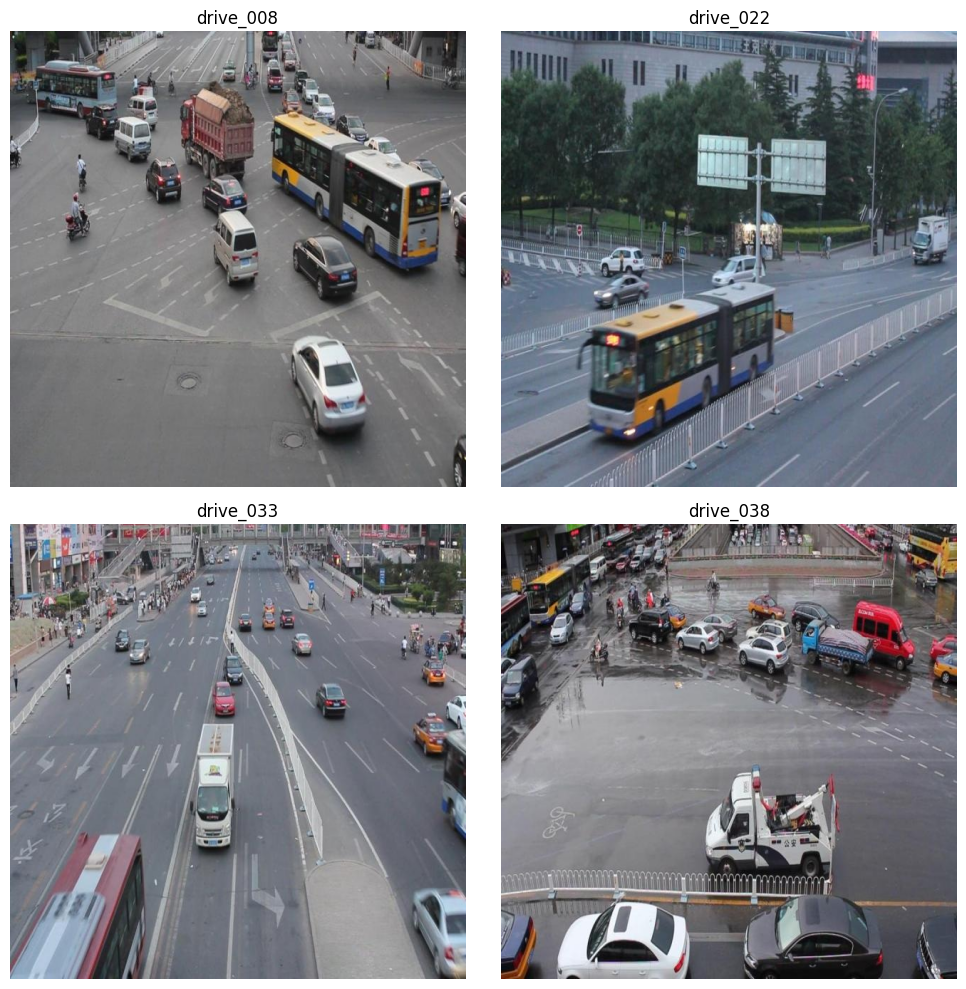

ĐẠT kiểm tra bộ ảnh. Đây phải là gói ZIP đã dùng trong CVAT; không thay ảnh hoặc tải bộ khác lên.


In [9]:
# 1 — Kiểm gói day2-cvat-input.zip được cấp: phải có đúng bốn ảnh.
# Ô lệnh này không tạo hoặc tải ảnh từ Internet.
input_name, input_payload = read_one_upload(
    "/content/day2-cvat-input.zip",
    "Chọn file data/day2-cvat-input.zip vừa tải từ repository",
)
INPUT_ZIP = UPLOAD_DIR / "day2-cvat-input.zip"
INPUT_ZIP.write_bytes(input_payload)
if sha256_file(INPUT_ZIP) != INPUT_ZIP_SHA256:
    raise ValueError("Sai checksum day2-cvat-input.zip; tải lại từ repository, không tự thay ảnh.")
input_root = safe_extract_zip(INPUT_ZIP, WORK_DIR / "input-images")
expected_ids = [row["image_id"] for row in manifest_rows]
actual_images = sorted(path for path in input_root.iterdir() if path.suffix.lower() in IMAGE_SUFFIXES)
if [path.stem for path in actual_images] != sorted(expected_ids):
    raise ValueError(f"ZIP phải có đúng {sorted(expected_ids)}, nhận {[p.stem for p in actual_images]}")
manifest_by_id = {row["image_id"]: row for row in manifest_rows}
for path in actual_images:
    row = manifest_by_id[path.stem]
    if sha256_file(path) != row["sha256"]:
        raise ValueError(f"Checksum ảnh sai: {path.name}")
    with Image.open(path) as image:
        if image.size != (row["width"], row["height"]):
            raise ValueError(f"Kích thước ảnh sai: {path.name}")
input_audit = {
    "archive_sha256": sha256_file(INPUT_ZIP),
    "image_ids": sorted(expected_ids),
    "image_count": len(actual_images),
    "provided_input_is_unchanged": True,
}
(OUTPUT_DIR / "input_pool_audit.json").write_text(json.dumps(input_audit, indent=2) + "\n", encoding="utf-8")
write_attribution(manifest_rows, OUTPUT_DIR / "IMAGE_ATTRIBUTION.md")
fig, axes = plt.subplots(2, 2, figsize=(10, 10))
for axis, path in zip(axes.flat, actual_images):
    axis.imshow(Image.open(path)); axis.set_title(path.stem); axis.axis("off")
plt.tight_layout(); plt.show()
print("ĐẠT kiểm tra bộ ảnh. Đây phải là gói ZIP đã dùng trong CVAT; không thay ảnh hoặc tải bộ khác lên.")


In [25]:
# 3a — Tải lên và kiểm gói Ultralytics YOLO của chính bạn.
name, payload = read_one_upload(
    "/content/day2-my-export.zip",
    "Chọn đúng một Ultralytics YOLO Detection ZIP của bạn",
)
MY_YOLO_EXPORT = UPLOAD_DIR / "mine-yolo.zip"
MY_YOLO_EXPORT.write_bytes(payload)
my_audit, my_records = audit_yolo_export(
    MY_YOLO_EXPORT, WORK_DIR / "mine-yolo", manifest_rows, EXPECTED_CLASS_NAMES
)
write_audit_report(my_audit, OUTPUT_DIR / "my_export_audit.json")
print(json.dumps(public_audit_report(my_audit), ensure_ascii=False, indent=2))
if not my_audit["within_slide_workload_target"]:
    print("CẦN KIỂM TRA: số hộp ngoài khoảng 40–60. Ghi số thật và rà phạm vi; không vẽ ẩu để đủ số.")


Chọn đúng một Ultralytics YOLO Detection ZIP của bạn


Saving job_1_dataset_2026_09_14_09_07_27_ultralytics yolo detection 1.0-fixed.zip to job_1_dataset_2026_09_14_09_07_27_ultralytics yolo detection 1.0-fixed (1).zip
{
  "archive_name": "mine-yolo.zip",
  "archive_sha256": "1e8ecb3acf0ed34700b49da1ca9fbfdaa2d1a3bdece4bdee9d5ca5f09d15c500",
  "class_names": [
    "car",
    "truck",
    "bus",
    "van"
  ],
  "image_ids": [
    "drive_022",
    "drive_033",
    "drive_038",
    "drive_008"
  ],
  "image_count": 4,
  "object_count": 79,
  "within_slide_workload_target": false,
  "coordinate_format": "normalized xywh",
  "images": {
    "drive_022": {
      "width": 640,
      "height": 640,
      "object_count": 4,
      "class_count": {
        "car": 2,
        "truck": 0,
        "bus": 1,
        "van": 1
      }
    },
    "drive_033": {
      "width": 640,
      "height": 640,
      "object_count": 27,
      "class_count": {
        "car": 22,
        "truck": 0,
        "bus": 3,
        "van": 2
      }
    },
    "drive_038": {
 

In [26]:
# 3b — Tải lên gói CVAT gốc của cùng tác vụ để kiểm các thuộc tính.
native_name, native_payload = read_one_upload(
    "/content/day2-native-export.zip",
    "Chọn đúng một CVAT for images 1.1 ZIP của bạn",
)
MY_NATIVE_EXPORT = UPLOAD_DIR / "mine-native.zip"
MY_NATIVE_EXPORT.write_bytes(native_payload)
my_native_audit = audit_cvat_images_export(
    MY_NATIVE_EXPORT, WORK_DIR / "mine-native", manifest_rows, EXPECTED_CLASS_NAMES
)
same_state_audit = verify_same_annotation_state(
    my_records, my_native_audit["_records"], [row["image_id"] for row in manifest_rows]
)
my_native_audit["cross_format_consistency"] = same_state_audit
write_audit_report(my_native_audit, OUTPUT_DIR / "my_native_export_audit.json")
print(json.dumps(public_audit_report(my_native_audit), ensure_ascii=False, indent=2))
print("ĐẠT kiểm tra cùng trạng thái:", json.dumps(same_state_audit, ensure_ascii=False))


Chọn đúng một CVAT for images 1.1 ZIP của bạn


Saving job_1_dataset_2026_09_14_08_14_58_cvat for images 1.1-fixed.zip to job_1_dataset_2026_09_14_08_14_58_cvat for images 1.1-fixed (4).zip
{
  "archive_name": "mine-native.zip",
  "archive_sha256": "8c9f57f967d455cf8de866218c1cc6dd9cc8cd2aef8c5d934f1334f6c390da6e",
  "format": "CVAT for images XML",
  "class_names": [
    "car",
    "truck",
    "bus",
    "van"
  ],
  "image_ids": [
    "drive_022",
    "drive_033",
    "drive_038",
    "drive_008"
  ],
  "image_count": 4,
  "object_count": 79,
  "within_slide_workload_target": false,
  "required_attributes": [
    "boundary",
    "review_state",
    "visibility"
  ],
  "attribute_value_count_by_name": {
    "visibility": 79,
    "boundary": 79,
    "review_state": 79
  },
  "images": {
    "drive_022": {
      "width": 640,
      "height": 640,
      "object_count": 4,
      "class_count": {
        "car": 2,
        "truck": 0,
        "bus": 1,
        "van": 1
      }
    },
    "drive_033": {
      "width": 640,
      "height"

In [19]:
# 3c — Đọc một dòng YOLO thật: lớp, tâm ngang, tâm dọc, chiều rộng, chiều cao.
if not my_records:
    print("CẦN KIỂM TRA: gói xuất không có hộp hợp lệ; quay lại CVAT, không tạo dòng giả để qua bước này.")
else:
    first_record = my_records[0]
    class_id = first_record["class_id"]
    x_center, y_center, width, height = first_record["bbox_xywh_normalized"]
    print("row:", [class_id, x_center, y_center, width, height])
    print(f"lớp={class_id} ({first_record['class_name']}) | tâm=({x_center:.4f}, {y_center:.4f}) | kích thước=({width:.4f}, {height:.4f})")
    print("pixel xyxy:", [round(v, 1) for v in first_record["bbox_xyxy_pixels"]])
    print("Câu hỏi cuối bước: vì sao dòng đúng định dạng vẫn có thể sai lớp, phạm vi hoặc hình học?")


row: [1, 0.397008, 0.73007, 0.475266, 0.371109]
lớp=1 (truck) | tâm=(0.3970, 0.7301) | kích thước=(0.4753, 0.3711)
pixel xyxy: [102.0, 348.5, 406.2, 586.0]
Câu hỏi cuối bước: vì sao dòng đúng định dạng vẫn có thể sai lớp, phạm vi hoặc hình học?


New https://pypi.org/project/ultralytics/8.4.151 available 😃 Update with 'pip install -U ultralytics'
Ultralytics 8.4.145 🚀 Python-3.13.15 torch-2.11.0+cpu CPU (AMD EPYC 7B12)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=4, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/day2_lab/dataset/data.yaml, degrees=0.0, deterministic=True, device=cpu, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=8, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=10, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=/content/day2

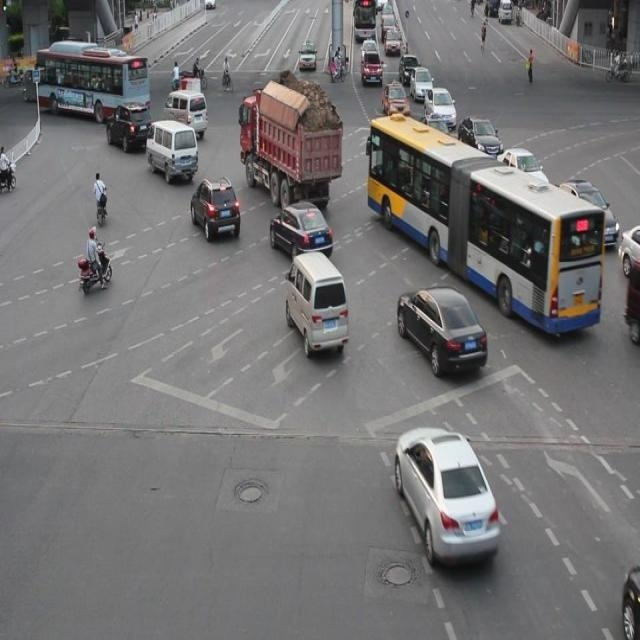

Hãy đọc kết quả dự đoán cụ thể; không dùng mAP của bốn ảnh để kết luận chất lượng người gán nhãn hay khả năng dùng trong thực tế.


In [20]:
# 4 — Huấn luyện và dự đoán thử trên ba ảnh huấn luyện, một ảnh kiểm tra.
# Đây không phải phép đánh giá chính thức và không phải điểm của người gán nhãn.
MODEL_ASSET = {
    "url": "https://github.com/ultralytics/assets/releases/download/v8.4.0/yolo11n.pt",
    "sha256": "0ebbc80d4a7680d14987a577cd21342b65ecfd94632bd9a8da63ae6417644ee1",
}
MODEL_PATH = download_with_sha256("yolo11n.pt", MODEL_ASSET["url"], WORK_DIR / "yolo11n.pt", MODEL_ASSET["sha256"])
DATA_YAML = build_training_dataset(my_audit, manifest_rows, EXPECTED_CLASS_NAMES, WORK_DIR / "dataset")
TRAIN_EPOCHS = 8
TRAIN_SEED = 42
DEVICE = 0 if torch.cuda.is_available() else "cpu"
started = time.time()
model = YOLO(str(MODEL_PATH))
train_result = model.train(
    data=str(DATA_YAML), epochs=TRAIN_EPOCHS, imgsz=640, batch=4, freeze=10,
    patience=3, seed=TRAIN_SEED, deterministic=True, device=DEVICE, workers=2,
    project=str(WORK_DIR / "runs"), name="day2-diagnostic", exist_ok=True, plots=True, verbose=False,
)
run_dir = Path(train_result.save_dir)
trained_model = YOLO(str(run_dir / "weights" / "best.pt"))
predict_image_id = next(row["image_id"] for row in manifest_rows if row["split"] == "val")
prediction = trained_model.predict(
    source=my_audit["images"][predict_image_id]["image_path"], conf=0.25, device=DEVICE, verbose=False
)[0]
prediction.save(filename=str(OUTPUT_DIR / "detect_result.jpg"))
training_run = {
    "purpose": "chỉ dùng để phản hồi và tìm lỗi dữ liệu",
    "not_production_benchmark": True,
    "ultralytics_version": ultralytics.__version__,
    "model_file": MODEL_PATH.name,
    "model_sha256": sha256_file(MODEL_PATH),
    "export_sha256": my_audit["archive_sha256"],
    "epochs": TRAIN_EPOCHS,
    "seed": TRAIN_SEED,
    "device": str(DEVICE),
    "train_image_ids": [r["image_id"] for r in manifest_rows if r["split"] == "train"],
    "val_image_ids": [r["image_id"] for r in manifest_rows if r["split"] == "val"],
    "elapsed_seconds": round(time.time() - started, 2),
}
(OUTPUT_DIR / "training_run.json").write_text(json.dumps(training_run, indent=2) + "\n", encoding="utf-8")
print(json.dumps(training_run, ensure_ascii=False, indent=2))
display(Image.open(OUTPUT_DIR / "detect_result.jpg"))
print("Hãy đọc kết quả dự đoán cụ thể; không dùng mAP của bốn ảnh để kết luận chất lượng người gán nhãn hay khả năng dùng trong thực tế.")


In [27]:
# 5a — Chọn nguồn đối chiếu sau khi bài riêng đã được kiểm và huấn luyện thử.
work_mode = input("Chọn 1 (cá nhân) hoặc 2 (theo cặp): ").strip()
if work_mode == "1":
    COMPARISON_ROLE = "teaching_reference"
    COMPARISON_LABEL = "bộ nhãn đối chiếu do Lab Coach cấp"
elif work_mode == "2":
    COMPARISON_ROLE = "peer"
    COMPARISON_LABEL = "gói YOLO độc lập của bạn cùng cặp"
else:
    raise ValueError("Chỉ nhập 1 hoặc 2. Chạy lại cell này.")
print("Nguồn đối chiếu:", COMPARISON_LABEL)


Chọn 1 (cá nhân) hoặc 2 (theo cặp): 1
Nguồn đối chiếu: bộ nhãn đối chiếu do Lab Coach cấp


In [28]:
# 5b — Tải nguồn đối chiếu lên. Không dùng lại gói xuất của chính bạn.
comparison_name, comparison_payload = read_one_upload(
    "/content/day2-comparison-export.zip",
    f"Chọn ZIP của {COMPARISON_LABEL}",
)
COMPARISON_YOLO_EXPORT = UPLOAD_DIR / "comparison.zip"
COMPARISON_YOLO_EXPORT.write_bytes(comparison_payload)
if sha256_file(COMPARISON_YOLO_EXPORT) == my_audit["archive_sha256"]:
    raise ValueError("Nguồn đối chiếu trùng gói xuất của bạn; cần một nguồn độc lập.")
comparison_audit, comparison_records = audit_yolo_export(
    COMPARISON_YOLO_EXPORT, WORK_DIR / "comparison", manifest_rows, EXPECTED_CLASS_NAMES
)
print(f"ĐẠT kiểm tra nguồn đối chiếu | nguồn={COMPARISON_ROLE} | số vật thể={comparison_audit['object_count']}")


Chọn ZIP của bộ nhãn đối chiếu do Lab Coach cấp


Saving day2-teaching-reference.zip to day2-teaching-reference.zip
ĐẠT kiểm tra nguồn đối chiếu | nguồn=teaching_reference | số vật thể=50


{
  "matching": "ghép tối ưu theo IoU hình học, không dùng lớp khi ghép",
  "comparison_iou_floor": 0.01,
  "floor_is_official_pass_threshold": false,
  "calibration_image_ids": [
    "drive_022",
    "drive_033",
    "drive_038",
    "drive_008"
  ],
  "matched_boxes": 31,
  "mean_iou": 0.77275,
  "median_iou": 0.788319,
  "class_agreement": 0.677419,
  "unmatched_mine": 48,
  "unmatched_comparison": 19,
  "comparison_source": "teaching_reference",
  "interpretation_warning": "Bộ nhãn đối chiếu hỗ trợ phản hồi sau bài làm độc lập; đây không phải kết luận chất lượng sản xuất.",
  "comparison_export_sha256": "f9ea9d085e65bfc9fd2a0567a425294b1db1322cc2ae26ef14312f42cf2b8c56"
}


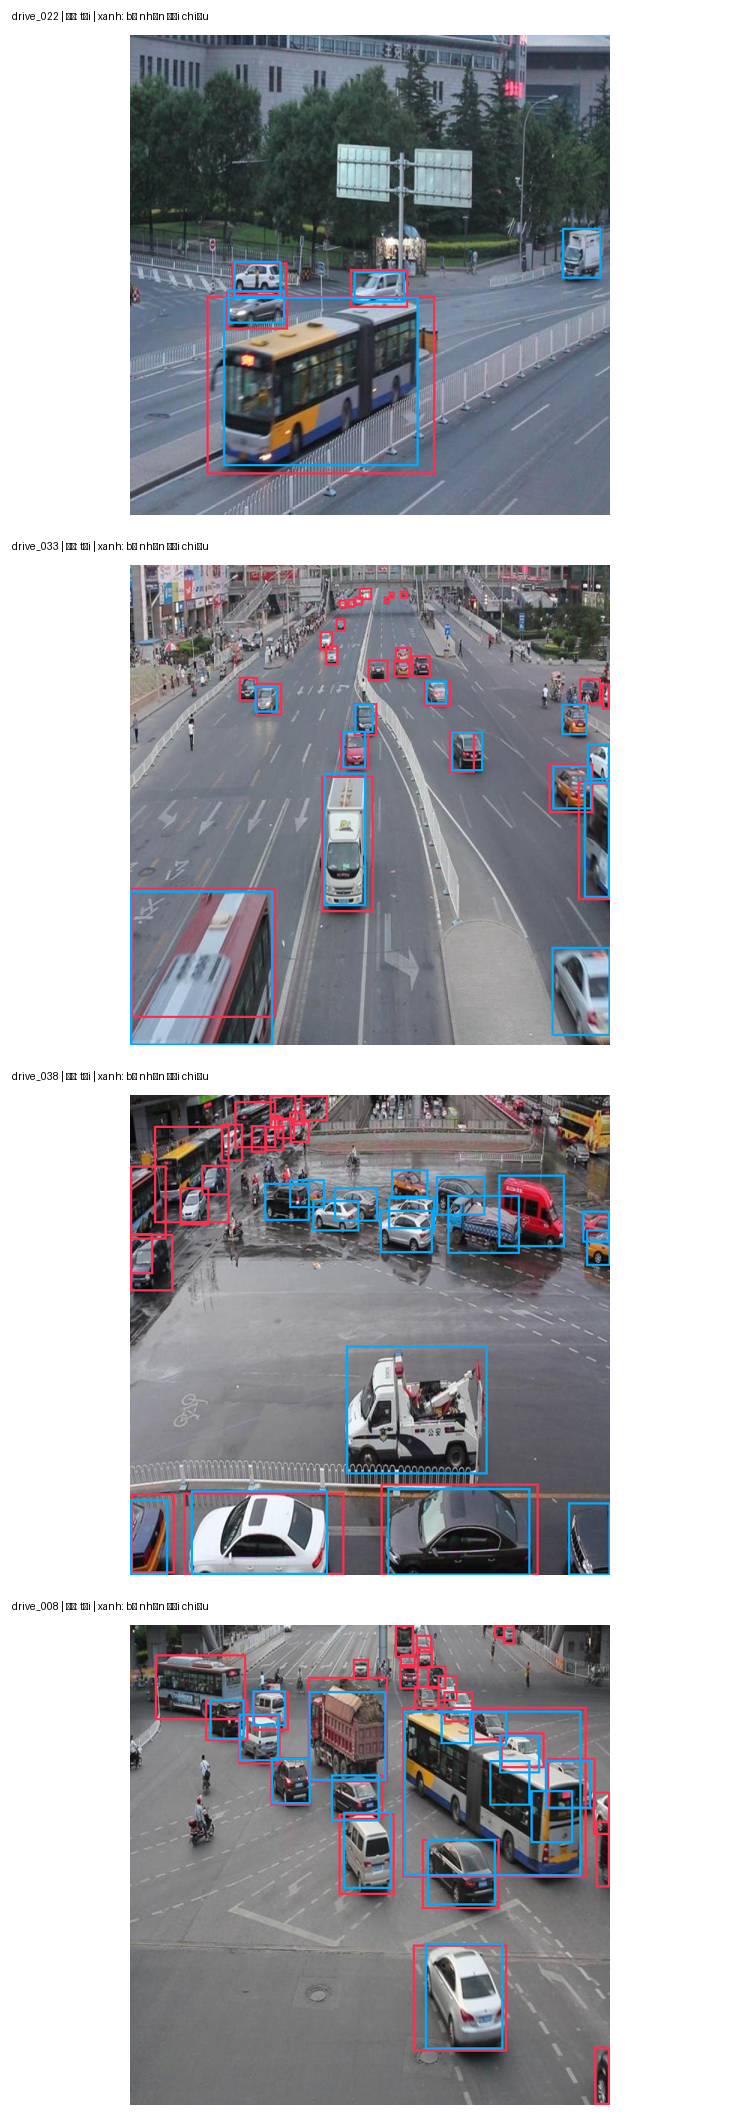

Bộ nhãn đối chiếu hỗ trợ phản hồi sau bài làm độc lập; đây không phải kết luận chất lượng sản xuất.


In [29]:
# 5c — Đối chiếu IoU: ghép theo hình học, rồi báo riêng lớp và các hộp không ghép được.
comparison_ids = [row["image_id"] for row in manifest_rows if row["role"] == "comparison"]
COMPARISON_IOU_FLOOR = 0.01  # tham số ghép kỹ thuật, KHÔNG phải ngưỡng đạt
comparison_summary, comparison_rows = compare_annotation_records(
    my_records, comparison_records, comparison_ids, COMPARISON_ROLE, COMPARISON_IOU_FLOOR
)
comparison_summary["comparison_export_sha256"] = comparison_audit["archive_sha256"]
write_annotation_comparison(comparison_summary, comparison_rows, OUTPUT_DIR)
create_comparison_overlay(
    my_audit, my_records, comparison_records, comparison_ids,
    OUTPUT_DIR / "comparison_overlay.png", COMPARISON_ROLE,
)
print(json.dumps(comparison_summary, ensure_ascii=False, indent=2))
display(Image.open(OUTPUT_DIR / "comparison_overlay.png"))
print(comparison_summary["interpretation_warning"])


## 6 — Sửa nhãn có căn cứ

Mở ảnh phủ hộp, các báo cáo JSON, ảnh dự đoán và hai tệp mẫu. Chọn một điểm khác biệt về phạm vi, lớp hoặc hình
học; dẫn quy tắc, sửa trong CVAT nếu cần, rồi mô tả trước và sau khi sửa. Không sửa TXT bằng tay để làm chỉ số
đẹp hơn. Cả hình thức cá nhân và theo cặp đều nộp cùng một bộ minh chứng.


In [32]:
# 7 — Kiểm tra và tạo ZIP chuyển tệp cho kho GitHub cá nhân.
# ZIP này chỉ giúp tải tệp từ Colab về máy, không phải bài nộp trên VLearn.
# Không đưa gói xuất thô, bộ nhãn đối chiếu hoặc trọng số mô hình vào kho cá nhân.
required_outputs = {
    "IMAGE_ATTRIBUTION.md", "input_pool_audit.json", "my_export_audit.json",
    "my_native_export_audit.json", "training_run.json", "detect_result.jpg",
    "comparison_iou.csv", "comparison_summary.json", "comparison_overlay.png",
}
actual_outputs = {path.name for path in OUTPUT_DIR.iterdir() if path.is_file()}
missing = required_outputs - actual_outputs
if missing:
    raise ValueError(f"Thiếu output: {sorted(missing)}")
for path in (REPORT_PATH, GUIDELINE_PATH):
    if not path.is_file():
        raise ValueError(f"Thiếu {path}")
    text = path.read_text(encoding="utf-8")
    if "CHƯA ĐIỀN" in text:
        raise ValueError(f"{path.name} còn placeholder; mở file và điền trước khi chạy lại.")

staging = Path("day2_repository_staging")
if staging.exists():
    shutil.rmtree(staging)
(staging / OUTPUT_DIR.name).mkdir(parents=True)
shutil.copy2(REPORT_PATH, staging / REPORT_PATH.name)
shutil.copy2(GUIDELINE_PATH, staging / GUIDELINE_PATH.name)
for filename in sorted(required_outputs):
    shutil.copy2(OUTPUT_DIR / filename, staging / OUTPUT_DIR.name / filename)
student_name = input("Nhập họ tên không dấu, nối các từ bằng dấu gạch ngang: ").strip()
student_id = input("Nhập MSSV: ").strip()
if not re.fullmatch(r"[A-Za-z]+(?:-[A-Za-z]+)+", student_name):
    raise ValueError("Họ tên phải không dấu và có dấu gạch ngang, ví dụ Nguyen-Van-An.")
if not re.fullmatch(r"[A-Za-z0-9_-]{4,24}", student_id):
    raise ValueError("MSSV chỉ dùng chữ, số, dấu gạch ngang hoặc gạch dưới; độ dài từ 4 đến 24 ký tự.")
repository_name = f"KX-DAY02-{student_name}-{student_id}"
transfer_archive = Path(f"{repository_name}-repo-files.zip")
with zipfile.ZipFile(transfer_archive, "w", compression=zipfile.ZIP_DEFLATED) as archive:
    for path in sorted(staging.rglob("*")):
        if path.is_file():
            archive.write(path, path.relative_to(staging))
roots = {Path(name).parts[0] for name in zipfile.ZipFile(transfer_archive).namelist()}
assert roots == {"REPORT.md", "GUIDELINE_MINI_SHEET.md", "day2_lab_outputs"}
assert zipfile.ZipFile(transfer_archive).testzip() is None
print("ĐẠT kiểm tra tệp cho kho cá nhân:", repository_name)
print("Tải gói chuyển tệp về máy:", transfer_archive.resolve())
print("Giải nén, đưa ba mục ở cấp đầu lên kho GitHub cá nhân, rồi nộp đường dẫn kho trên VLearn.")


ValueError: REPORT.md còn placeholder; mở file và điền trước khi chạy lại.